# 1. Check Paths

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()

# se il notebook viene eseguito dalla cartella notebooks/
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

physics_model_dir = (
    ROOT
    / "external"
    / "thomas-wflo-benchmark"
    / "src"
    / "physics-models"
)

sys.path.append(str(physics_model_dir))

BENCHMARK_ROOT = ROOT / "external" / "thomas-wflo-benchmark"

BOUNDARY_FILE = (
    BENCHMARK_ROOT
    / "src"
    / "input-files"
    / "farms"
    / "iea37-boundary-cs4.yaml"
)

WIND_FILE = (
    BENCHMARK_ROOT
    / "src"
    / "input-files"
    / "wind"
    / "iea37-windrose-cs4.yaml"
)

TURBINE_FILE = (
    BENCHMARK_ROOT
    / "src"
    / "input-files"
    / "turbines"
    / "iea37-10mw.yaml"
)

PHYSICS_DIR = (
    BENCHMARK_ROOT
    / "src"
    / "physics-models"
)

RESULTS_DIR = (
    BENCHMARK_ROOT
    / "results"
    / "optimization-results"
)

 
assert BENCHMARK_ROOT.exists()
assert BOUNDARY_FILE.exists()
assert WIND_FILE.exists()
assert TURBINE_FILE.exists()
assert PHYSICS_DIR.exists()
assert RESULTS_DIR.exists()

print("Benchmark found:", BENCHMARK_ROOT)

Benchmark found: /home/maicolnicolini/code/qubo-wind-farm-layout/external/thomas-wflo-benchmark


# 2. Execute Evaluator

In [2]:
import subprocess
import sys

result = subprocess.run(
    [sys.executable, "provided_model.py"],
    cwd=PHYSICS_DIR,
    capture_output=True,
    text=True,
)

print(result.stdout)

if result.stderr:
    print(result.stderr)

Base :  2851096.41252  MWh
WEC :  2910115.64377  MWh
DEBO :  2913220.60417  MWh
GPS :  2905646.37897  MWh
CMA-ES :  2906607.55452  MWh
GA-GB :  2907540.96474  MWh
ADREMOG :  2909489.25914  MWh
ADREMOG+PG :  2907615.06525  MWh
DPA :  2910537.86749  MWh



# 3. Understand the data

In [3]:
import yaml

with open(BOUNDARY_FILE) as f:
    boundary_data = yaml.safe_load(f)

with open(WIND_FILE) as f:
    wind_data = yaml.safe_load(f)

with open(TURBINE_FILE) as f:
    turbine_data = yaml.safe_load(f)

# 4. Visualize the problem

In [ ]:
! pip install pyyaml shapely matplotlib - q

In [4]:
import yaml
import matplotlib.pyplot as plt

from shapely.geometry import Polygon

with open(BOUNDARY_FILE) as f:
    boundary_data = yaml.safe_load(f)


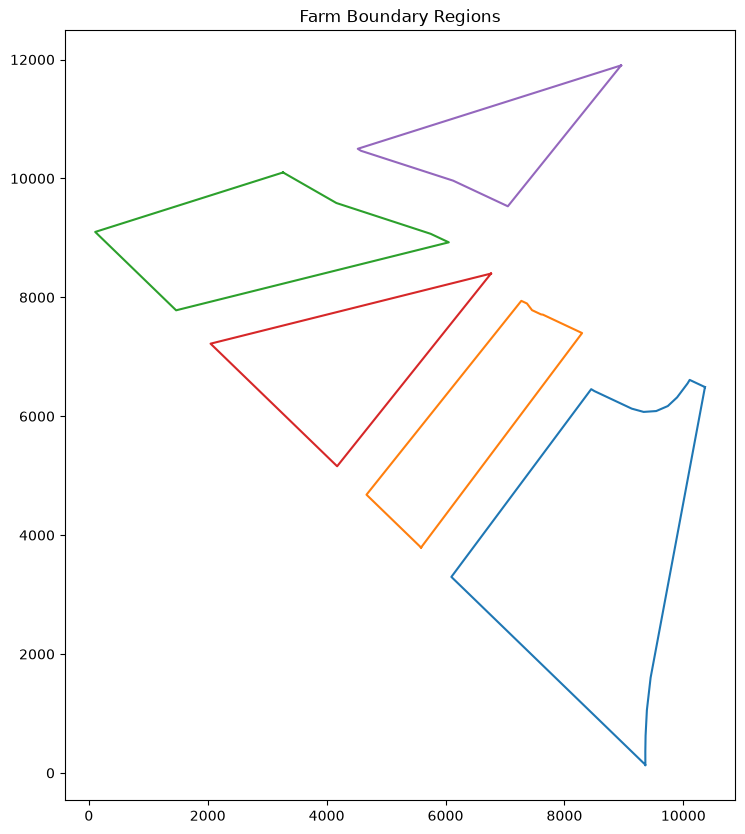

In [5]:
region_names = boundary_data['boundaries'].keys()

polygons = []

for region_name in region_names:
    region_coords = boundary_data['boundaries'][region_name]
    polygon = Polygon(region_coords)
    polygons.append(polygon)


fig, ax = plt.subplots(figsize=(10, 10))

for polygon in polygons:
    x, y = polygon.exterior.xy
    ax.plot(x, y)

ax.set_aspect("equal")
ax.set_title("Farm Boundary Regions")
plt.show()

In [6]:
# Calculate AEP

import numpy as np
from provided_model import getTurbLocYAML, getTurbAtrbtYAML, getWindRoseYAML, calcAEPcs3

def calculate_aep(filepath):

    #-- Read necessary values from .yaml files --#
    # Get turbine locations and auxiliary <.yaml> filenames
    # turb_coords, fname_turb, fname_wr = getTurbLocYAML("../input-files/farms/iea37-ex-opt4.yaml")
    turb_coords, fname_turb, fname_wr = getTurbLocYAML(filepath)
    # Get the array wind sampling bins, frequency at each bin, and wind speed
    wind_dir, wind_dir_freq, wind_speeds, wind_speed_probs, num_speed_bins, min_speed, max_speed = getWindRoseYAML(
        "../external/thomas-wflo-benchmark/src/input-files/wind/"+fname_wr)
    # Pull the needed turbine attributes from file
    turb_ci, turb_co, rated_ws, rated_pwr, turb_diam = getTurbAtrbtYAML(
        "../external/thomas-wflo-benchmark/src/input-files/turbines/"+fname_turb)

    #-- Calculate the AEP from ripped values --#
    AEP = calcAEPcs3(turb_coords, wind_dir_freq, wind_speeds, wind_speed_probs, wind_dir,
                turb_diam, turb_ci, turb_co, rated_ws, rated_pwr)
    return AEP


diraep = calculate_aep(filepath=f"{RESULTS_DIR}/base.yaml")
 
AEP = np.around(np.sum(diraep), decimals=5)

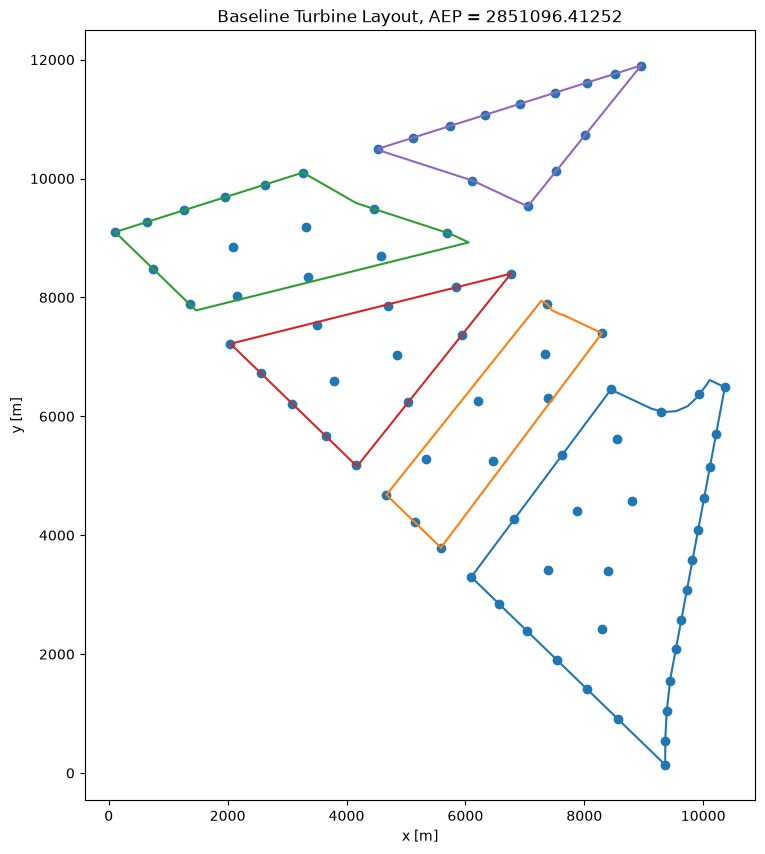

In [7]:
with open(f"{RESULTS_DIR}/debo.yaml") as f:
    base_data = yaml.safe_load(f)

baseline  = base_data['definitions']['position']['items']

fig, ax = plt.subplots(figsize=(10, 10))

for polygon in polygons:
    x, y = polygon.exterior.xy
    ax.plot(x, y)

ax.scatter(
    [p[0] for p in baseline],
    [p[1] for p in baseline],
)

ax.set_aspect("equal")
ax.set_title(f"Baseline Turbine Layout, AEP = {AEP}")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")

plt.show()